### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading


In [3]:
# Load the dataset
df = pd.read_csv('lung_cancer.csv')

# Display the first 5 rows
df.head()

,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
0,60,1,20,2,1,16,15,12,0,71,...,20,94,29,6,1,5,4,13,3,1
1,53,0,12,4,0,0,0,0,1,66,...,25,96,35,4,0,5,2,0,3,0
2,62,1,15,3,1,9,29,13,1,69,...,23,95,29,9,1,1,4,2,1,1
3,73,1,12,3,0,0,0,0,0,47,...,18,96,32,0,0,0,3,10,4,0
4,52,1,13,1,0,0,0,0,0,94,...,16,97,36,8,0,6,2,9,2,0


In [3]:
# Check the size of the dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 5000 rows and 30 columns.


In [4]:
# Display column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   age                      5000 non-null   int64
 1   gender                   5000 non-null   int64
 2   education_years          5000 non-null   int64
 3   income_level             5000 non-null   int64
 4   smoker                   5000 non-null   int64
 5   smoking_years            5000 non-null   int64
 6   cigarettes_per_day       5000 non-null   int64
 7   pack_years               5000 non-null   int64
 8   passive_smoking          5000 non-null   int64
 9   air_pollution_index      5000 non-null   int64
 10  occupational_exposure    5000 non-null   int64
 11  radon_exposure           5000 non-null   int64
 12  family_history_cancer    5000 non-null   int64
 13  copd                     5000 non-null   int64
 14  asthma                   5000 non-null   int64
 15  prev

In [5]:
# Summary statistics
df.describe()

,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000
mean,54.566400,0.488200,11.510400,2.554400,0.454800,8.822200,6.685600,6.249000,0.347600,64.278800,...,23.604800,96.089200,31.475800,4.593600,0.201400,2.580400,2.534800,5.8850,2.536800,0.248800
std,11.932731,0.499911,2.953987,0.982667,0.498003,11.651598,9.032888,9.964901,0.476256,19.479809,...,3.937222,3.412385,5.213679,5.333566,0.401086,1.834178,0.985385,4.4239,0.984093,0.432361
min,18.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,...,16.000000,85.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.0000,1.000000,0.000000
25%,47.000000,0.000000,10.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,51.000000,...,21.000000,95.000000,30.000000,1.000000,0.000000,1.000000,2.000000,2.0000,2.000000,0.000000
50%,55.000000,0.000000,11.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64.000000,...,24.000000,97.000000,33.000000,3.000000,0.000000,2.000000,3.000000,6.0000,3.000000,0.000000
75%,62.000000,1.000000,13.250000,3.000000,1.000000,18.000000,14.000000,10.000000,1.000000,78.000000,...,26.000000,99.000000,35.000000,7.000000,0.000000,4.000000,3.000000,9.0000,3.000000,0.000000
max,90.000000,1.000000,20.000000,5.000000,1.000000,52.000000,44.000000,60.000000,1.000000,130.000000,...,37.000000,100.000000,37.000000,33.000000,1.000000,10.000000,5.000000,23.0000,5.000000,1.000000


In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age                        0
gender                     0
education_years            0
income_level               0
smoker                     0
smoking_years              0
cigarettes_per_day         0
pack_years                 0
passive_smoking            0
air_pollution_index        0
occupational_exposure      0
radon_exposure             0
family_history_cancer      0
copd                       0
asthma                     0
previous_tb                0
chronic_cough              0
chest_pain                 0
shortness_of_breath        0
fatigue                    0
bmi                        0
oxygen_saturation          0
fev1_x10                   0
crp_level                  0
xray_abnormal              0
exercise_hours_per_week    0
diet_quality               0
alcohol_units_per_week     0
healthcare_access          0
lung_cancer_risk           0
dtype: int64


## 2. Exploratory Data Analysis


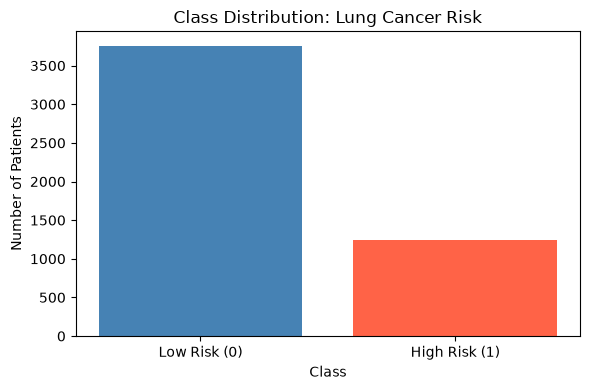

Low Risk  (0): 3756 (75.1%)
High Risk (1): 1244 (24.9%)


In [7]:
# Class distribution
class_counts = df['lung_cancer_risk'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(['Low Risk (0)', 'High Risk (1)'], class_counts.values, color=['steelblue', 'tomato'])
plt.title('Class Distribution: Lung Cancer Risk')
plt.xlabel('Class')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(f"Low Risk  (0): {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)")
print(f"High Risk (1): {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)")

In [8]:
# Compare key continuous features between risk groups
continuous_features = ['pack_years', 'crp_level', 'age', 'oxygen_saturation', 'fev1_x10', 'air_pollution_index']

group_means = df.groupby('lung_cancer_risk')[continuous_features].mean().round(2)
group_means.index = ['Low Risk (0)', 'High Risk (1)']
print("Mean values of continuous features by risk group:")
group_means

Mean values of continuous features by risk group:


,pack_years,crp_level,age,oxygen_saturation,fev1_x10,air_pollution_index
Low Risk (0),1.49,2.20,53.99,97.59,33.84,63.72
High Risk (1),20.63,11.83,56.30,91.55,24.35,65.97


In [4]:
# Compare key binary features between risk groups
binary_features = ['smoker', 'xray_abnormal', 'chronic_cough', 'copd', 'family_history_cancer', 'passive_smoking']

binary_means = df.groupby('lung_cancer_risk')[binary_features].mean().round(3)
binary_means.index = ['Low Risk (0)', 'High Risk (1)']
print("Proportion of binary features by risk group:")
binary_means

Proportion of binary features by risk group:


,smoker,xray_abnormal,chronic_cough,copd,family_history_cancer,passive_smoking
Low Risk (0),0.274,0.029,0.036,0.030,0.189,0.339
High Risk (1),1.000,0.723,0.586,0.551,0.248,0.375


## 3. Feature Selection

We compute the Pearson correlation between each feature and the target variable (`lung_cancer_risk`).
Features with a very low absolute correlation (below 0.05) contribute little signal and can be removed.


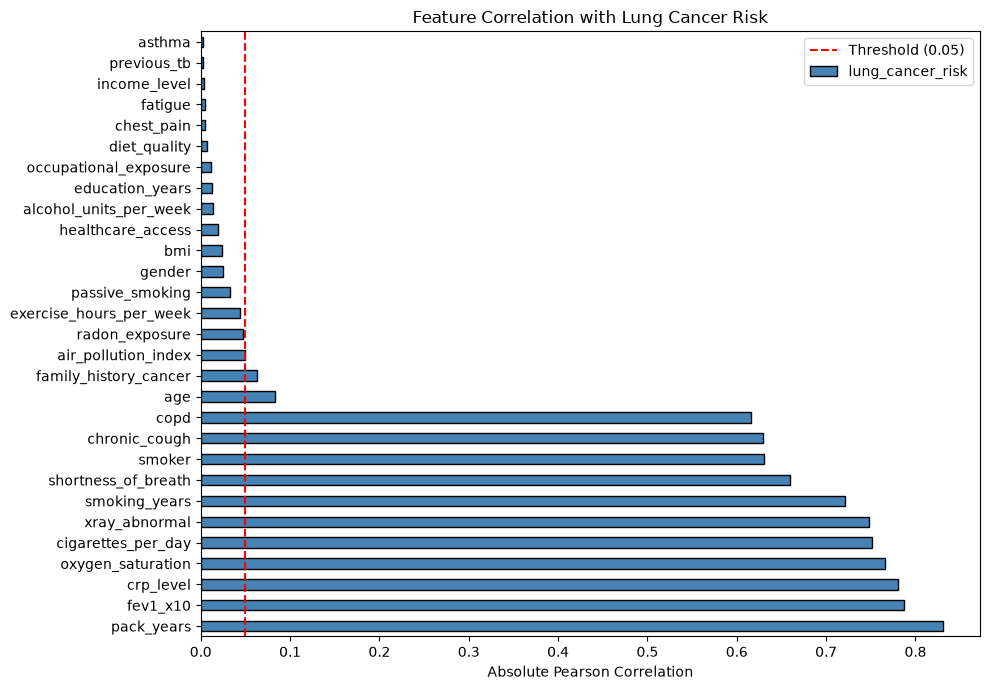


Correlation values:
pack_years                 0.830688
fev1_x10                   0.787038
crp_level                  0.780422
oxygen_saturation          0.766323
cigarettes_per_day         0.751001
xray_abnormal              0.748023
smoking_years              0.721593
shortness_of_breath        0.659022
smoker                     0.630108
chronic_cough              0.629583
copd                       0.616377
age                        0.083533
family_history_cancer      0.063177
air_pollution_index        0.050072
radon_exposure             0.047155
exercise_hours_per_week    0.043896
passive_smoking            0.032627
gender                     0.024692
bmi                        0.023898
healthcare_access          0.019642
alcohol_units_per_week     0.014125
education_years            0.012520
occupational_exposure      0.011745
diet_quality               0.007180
chest_pain                 0.005074
fatigue                    0.004591
income_level               0.003613
previou

In [9]:
# Compute correlation of each feature with the target
correlations = df.corr()['lung_cancer_risk'].drop('lung_cancer_risk').abs().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 7))
correlations.plot(kind='barh', color='steelblue', edgecolor='black')
plt.axvline(x=0.05, color='red', linestyle='--', label='Threshold (0.05)')
plt.title('Feature Correlation with Lung Cancer Risk')
plt.xlabel('Absolute Pearson Correlation')
plt.legend()
plt.tight_layout()
plt.show()

print("\nCorrelation values:")
print(correlations.to_string())

In [10]:
# Keep only features above the threshold
threshold = 0.05
selected_features = correlations[correlations >= threshold].index.tolist()

print(f"Features selected ({len(selected_features)}):")
for f in selected_features:
    print(f"  - {f}")

Features selected (14):
  - pack_years
  - fev1_x10
  - crp_level
  - oxygen_saturation
  - cigarettes_per_day
  - xray_abnormal
  - smoking_years
  - shortness_of_breath
  - smoker
  - chronic_cough
  - copd
  - age
  - family_history_cancer
  - air_pollution_index


## 4. Data Preprocessing

Steps:
1. Separate features (X) and target (y)
2. Apply **StandardScaler** to continuous features
3. Split into training (80%) and testing (20%) sets using stratification


In [11]:
# Separate features and target
X = df[selected_features]
y = df['lung_cancer_risk']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (5000, 14)
y shape: (5000,)


In [12]:
# Define which selected features are continuous (need scaling)
continuous_cols = ['age', 'education_years', 'smoking_years', 'cigarettes_per_day', 'pack_years',
                   'air_pollution_index', 'bmi', 'oxygen_saturation', 'fev1_x10', 'crp_level',
                   'exercise_hours_per_week', 'alcohol_units_per_week']

# Only scale the continuous columns that are present in selected features
cols_to_scale = [c for c in continuous_cols if c in X.columns]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

print("Scaling applied to:", cols_to_scale)
X_scaled.head()

Scaling applied to: ['age', 'smoking_years', 'cigarettes_per_day', 'pack_years', 'air_pollution_index', 'oxygen_saturation', 'fev1_x10', 'crp_level']


,pack_years,fev1_x10,crp_level,oxygen_saturation,cigarettes_per_day,xray_abnormal,smoking_years,shortness_of_breath,smoker,chronic_cough,copd,age,family_history_cancer,air_pollution_index
0,0.577183,-0.474914,0.263715,-0.612302,0.920551,1,0.616097,1,1,1,0,0.455398,0,0.345069
1,-0.627164,0.676020,-0.111306,-0.026143,-0.740214,0,-0.757242,0,0,0,0,-0.131282,1,0.088367
2,0.677546,-0.474914,0.826247,-0.319222,2.470598,1,0.015261,1,1,0,0,0.623021,0,0.242388
3,-0.627164,0.100553,-0.861349,-0.026143,-0.740214,0,-0.757242,0,0,0,0,1.544948,0,-0.887099
4,-0.627164,0.867843,0.638736,0.266937,-0.740214,0,-0.757242,0,0,0,0,-0.215094,0,1.525897


In [13]:
# Split into training (80%) and testing (20%) sets
# stratify=y ensures both sets have the same class ratio as the original dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size : {X_train.shape}")
print(f"Testing set size  : {X_test.shape}")

print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in test set:")
print(y_test.value_counts())

Training set size : (4000, 14)
Testing set size  : (1000, 14)

Class distribution in training set:
lung_cancer_risk
0    3005
1     995
Name: count, dtype: int64

Class distribution in test set:
lung_cancer_risk
0    751
1    249
Name: count, dtype: int64


## 5. K-Nearest Neighbour (KNN) Classifier


#### Step 1: Train with k=5 and evaluate:

In [14]:
# Train KNN with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict on the test set
y_pred_knn = knn.predict(X_test)

# Evaluate
print("--- KNN (k=5) Performance ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_knn):.4f}")

--- KNN (k=5) Performance ---
Accuracy : 0.9590
Precision: 0.9407
Recall   : 0.8916
F1-Score : 0.9155


#### Step 2: Find the optimal value of k:

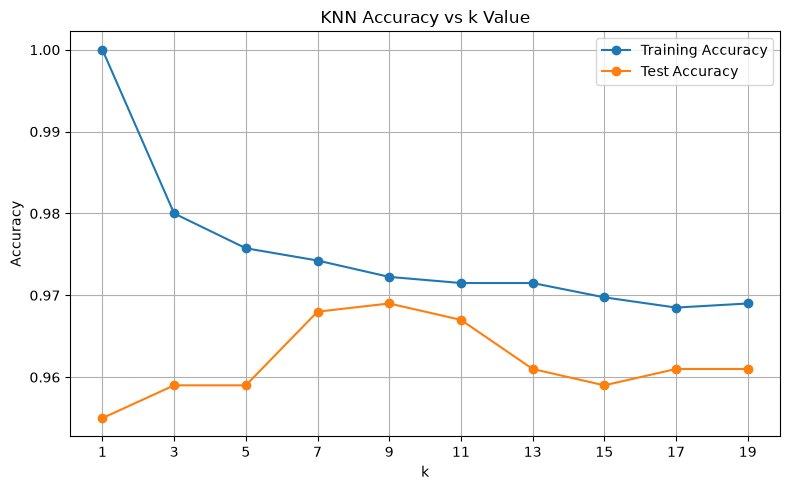

In [15]:
# Test different k values to find the best one
k_values = range(1, 21, 2)
train_accuracy = []
test_accuracy = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    train_accuracy.append(knn_k.score(X_train, y_train))
    test_accuracy.append(knn_k.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accuracy, marker='o', label='Training Accuracy')
plt.plot(k_values, test_accuracy, marker='o', label='Test Accuracy')
plt.title('KNN Accuracy vs k Value')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Step 3: Retrain with optimal k and final evaluation:

In [16]:
# Find the best k
optimal_k = list(k_values)[test_accuracy.index(max(test_accuracy))]
print(f"Optimal k: {optimal_k}")

# Retrain with optimal k
knn_best = KNeighborsClassifier(n_neighbors=optimal_k)
knn_best.fit(X_train, y_train)
y_pred_knn_best = knn_best.predict(X_test)

# Final metrics
print(f"\n--- KNN (k={optimal_k}) Final Performance ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_best):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_knn_best):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_knn_best):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn_best, target_names=['Low Risk', 'High Risk']))

Optimal k: 9

--- KNN (k=9) Final Performance ---
Accuracy : 0.9690
Precision: 0.9698
Recall   : 0.9036
F1-Score : 0.9356

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.97      0.99      0.98       751
   High Risk       0.97      0.90      0.94       249

    accuracy                           0.97      1000
   macro avg       0.97      0.95      0.96      1000
weighted avg       0.97      0.97      0.97      1000



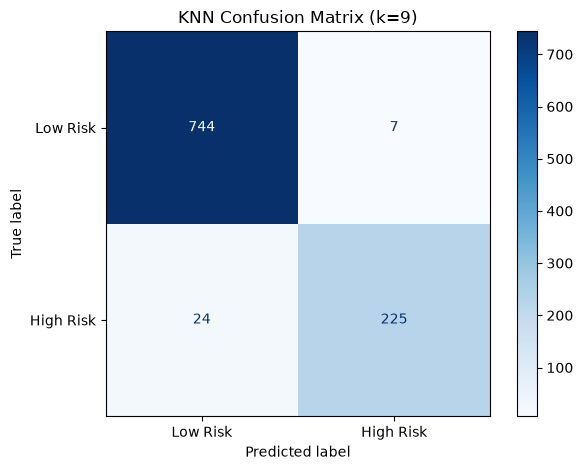

In [17]:
# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Low Risk', 'High Risk'])
disp.plot(cmap='Blues')
plt.title(f'KNN Confusion Matrix (k={optimal_k})')
plt.tight_layout()
plt.show()

## 6. Artificial Neural Network (ANN) Classifier


#### Step 1: Build the model:

In [18]:
# Build the ANN model
model = Sequential()

# Input layer (one neuron per feature)
model.add(Input(shape=(X_train.shape[1],)))

# First hidden layer: 16 neurons, ReLU activation
model.add(Dense(16, activation='relu'))

# Second hidden layer: 8 neurons, ReLU activation
model.add(Dense(8, activation='relu'))

# Output layer: 1 neuron, sigmoid (binary classification)
model.add(Dense(1, activation='sigmoid'))

# Display model structure
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

#### Step 2: Compile the model:

In [19]:
# Compile with Adam optimizer and binary cross-entropy loss
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#### Step 3: Train the model:

In [20]:
# Train the model for 30 epochs
history = model.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9178 - loss: 0.3563 - val_accuracy: 0.9475 - val_loss: 0.2078
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9450 - loss: 0.1548 - val_accuracy: 0.9525 - val_loss: 0.1242
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9550 - loss: 0.1118 - val_accuracy: 0.9613 - val_loss: 0.0991
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9594 - loss: 0.0934 - val_accuracy: 0.9650 - val_loss: 0.0852
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9653 - loss: 0.0811 - val_accuracy: 0.9725 - val_loss: 0.0755
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9684 - loss: 0.0725 - val_accuracy: 0.9712 - val_loss: 0.0681
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9725 - loss: 0.0660 - val_accuracy: 0.9725 - val_loss: 0.0642
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9756 - loss: 0.0614 - val_accuracy: 0.

#### Step 4: Plot the training history:

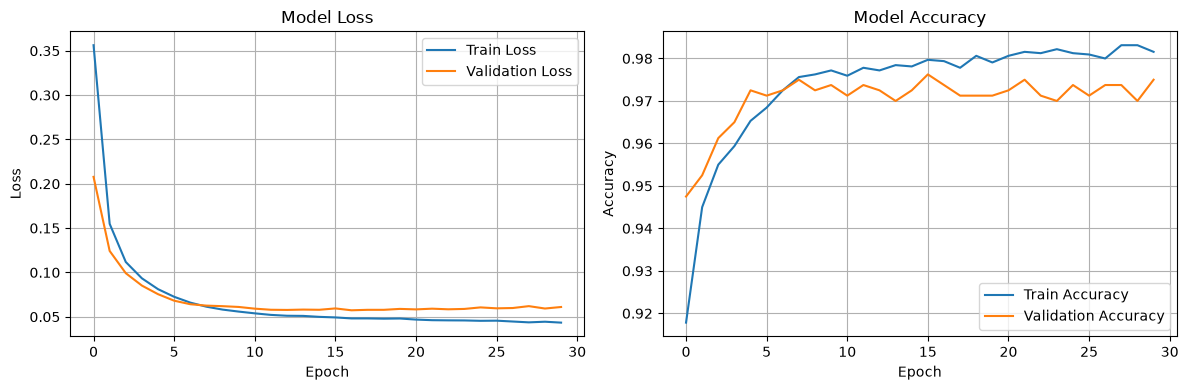

In [21]:
# Plot training and validation loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### Step 5: Evaluate the model:

In [22]:
# Evaluate on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss    : {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get predictions (convert probabilities to 0/1)
y_pred_prob = model.predict(X_test, verbose=0)
y_pred_ann = (y_pred_prob >= 0.5).astype(int).flatten()

# Full metrics
print("\n--- ANN Final Performance ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_ann):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ann):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_ann):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_ann):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann, target_names=['Low Risk', 'High Risk']))

Test Loss    : 0.0675
Test Accuracy: 0.9750

--- ANN Final Performance ---
Accuracy : 0.9750
Precision: 0.9746
Recall   : 0.9237
F1-Score : 0.9485

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.98      0.99      0.98       751
   High Risk       0.97      0.92      0.95       249

    accuracy                           0.97      1000
   macro avg       0.97      0.96      0.97      1000
weighted avg       0.97      0.97      0.97      1000



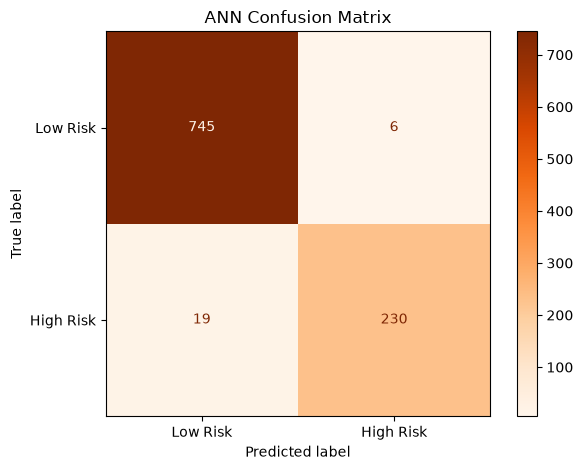

In [23]:
# Confusion Matrix
cm_ann = confusion_matrix(y_test, y_pred_ann)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=['Low Risk', 'High Risk'])
disp.plot(cmap='Oranges')
plt.title('ANN Confusion Matrix')
plt.tight_layout()
plt.show()

## 7. Model Comparison


In [24]:
# Summary comparison table
results = {
    'Model': [f'KNN (k={optimal_k})', 'ANN'],
    'Accuracy' : [accuracy_score(y_test, y_pred_knn_best), accuracy_score(y_test, y_pred_ann)],
    'Precision': [precision_score(y_test, y_pred_knn_best), precision_score(y_test, y_pred_ann)],
    'Recall'   : [recall_score(y_test, y_pred_knn_best), recall_score(y_test, y_pred_ann)],
    'F1-Score' : [f1_score(y_test, y_pred_knn_best), f1_score(y_test, y_pred_ann)],
}

results_df = pd.DataFrame(results).set_index('Model').round(4)
print(results_df.to_string())

           Accuracy  Precision  Recall  F1-Score
Model                                           
KNN (k=9)     0.969     0.9698  0.9036    0.9356
ANN           0.975     0.9746  0.9237    0.9485


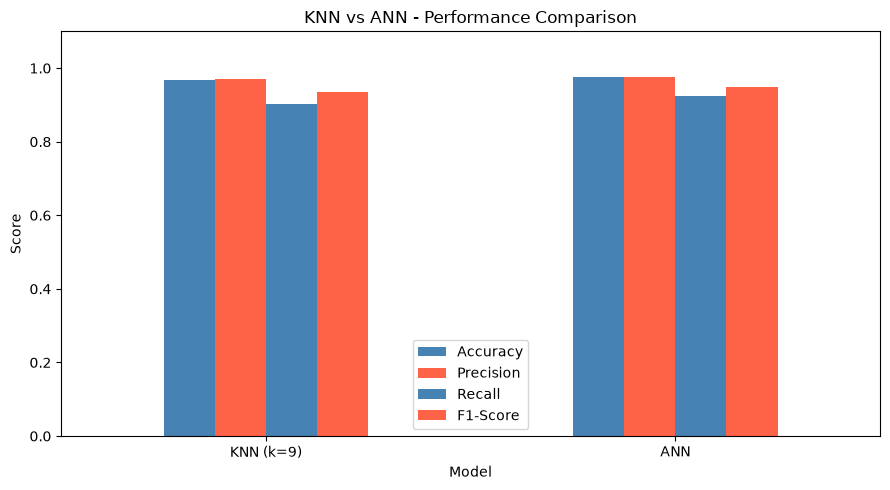

In [25]:
# Bar chart comparison
results_df.plot(kind='bar', figsize=(9, 5), color=['steelblue', 'tomato'])
plt.title('KNN vs ANN - Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()